<a href="https://colab.research.google.com/github/m1deey/Food_classification/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os
print("Data set path",path)
print("\nContents:")
print(os.listdir(path))

Data set path /root/.cache/kagglehub/datasets/dansbecker/food-101/versions/1

Contents:
['food-101.zip', 'food-101']


In [9]:
data_path=os.path.join(path,"food-101","food-101")
print(os.listdir(data_path))

['.DS_Store', 'README.txt', 'meta', 'images', 'license_agreement.txt']


In [11]:
images_path=os.path.join(data_path,"images")
print(os.listdir(images_path)[:20])

['.DS_Store', 'takoyaki', 'sushi', 'lasagna', 'tiramisu', 'grilled_cheese_sandwich', 'bread_pudding', 'tacos', 'sashimi', 'club_sandwich', 'bruschetta', 'pancakes', 'baby_back_ribs', 'dumplings', 'pork_chop', 'spaghetti_bolognese', 'falafel', 'frozen_yogurt', 'hummus', 'scallops']


In [13]:
images_path = os.path.join(data_path, "images")

classes = os.listdir(images_path)

print("Number of classes:", len(classes))
print("\nFirst 20 classes:")
print(classes[:20])

Number of classes: 102

First 20 classes:
['.DS_Store', 'takoyaki', 'sushi', 'lasagna', 'tiramisu', 'grilled_cheese_sandwich', 'bread_pudding', 'tacos', 'sashimi', 'club_sandwich', 'bruschetta', 'pancakes', 'baby_back_ribs', 'dumplings', 'pork_chop', 'spaghetti_bolognese', 'falafel', 'frozen_yogurt', 'hummus', 'scallops']


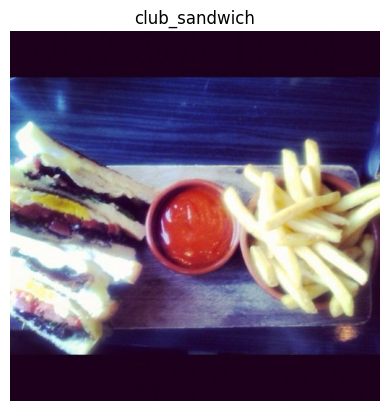

In [29]:
import matplotlib.pyplot as plt
from PIL import Image
import random
food_class=random.choice(classes)
class_path=os.path.join(images_path,food_class)
image_name=random.choice(os.listdir(class_path))
image_path=os.path.join(class_path,image_name)
image=Image.open(image_path)
plt.imshow(image)
plt.title(food_class)
plt.axis("off")
plt.show()

In [30]:
import tensorflow as tf
IMAGE=(224,224)
BATCH_SIZE=32
SEED=4211

In [34]:
meta_path=os.path.join(data_path,"meta")
print(os.listdir(meta_path))

['train.txt', 'labels.txt', 'classes.txt', 'train.json', 'test.json', 'test.txt']


In [36]:
train_file = os.path.join(meta_path, "train.txt")
test_file = os.path.join(meta_path, "test.txt")

with open(train_file, "r") as f:
    train_images = f.read().splitlines()

with open(test_file, "r") as f:
    test_images = f.read().splitlines()

print("Training images:", len(train_images))
print("Test images:", len(test_images))

print("\nExample:")
print(train_images[:5])

Training images: 75750
Test images: 25250

Example:
['apple_pie/1005649', 'apple_pie/1014775', 'apple_pie/1026328', 'apple_pie/1028787', 'apple_pie/1043283']


In [38]:
from sklearn.model_selection import train_test_split

train_list, val_list = train_test_split(
    train_images,
    test_size=0.20,
    random_state=42
)

print("Train:", len(train_list))
print("Validation:", len(val_list))
print("Test:", len(test_images))

Train: 60600
Validation: 15150
Test: 25250


In [39]:
def create_paths_and_labels(image_list):

    paths = []
    labels = []

    for item in image_list:

        class_name, image_name = item.split("/")

        image_path = os.path.join(
            images_path,
            class_name,
            image_name + ".jpg"
        )

        paths.append(image_path)
        labels.append(class_name)

    return paths, labels
train_paths, train_labels = create_paths_and_labels(train_list)
val_paths, val_labels = create_paths_and_labels(val_list)
test_paths, test_labels = create_paths_and_labels(test_images)

print(train_paths[0])
print(train_labels[0])

/root/.cache/kagglehub/datasets/dansbecker/food-101/versions/1/food-101/food-101/images/beet_salad/3685.jpg
beet_salad


In [47]:
classes = sorted(os.listdir(images_path))

class_to_index = {
    class_name: i
    for i, class_name in enumerate(classes)
}

print(class_to_index["apple_pie"])

if isinstance(train_labels[0], str):
    train_labels = [class_to_index[x] for x in train_labels]
    val_labels = [class_to_index[x] for x in val_labels]
    test_labels = [class_to_index[x] for x in test_labels]

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

1


In [48]:
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = (
    train_ds
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for images, labels in train_ds.take(1):
    print(images.shape, labels.shape)

(32, 224, 224, 3) (32,)


In [53]:
IMG_SIZE = (224, 224)
NUM_CLASSES = len(classes)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 102)            │       130,662 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,388,646 (9.11 MB)

 Trainable params: 130,662 (510.40 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 182s 90ms/step - accuracy: 0.3971 - loss: 2.5132 - val_accuracy: 0.5183 - val_loss: 1.9145
Epoch 2/10
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 167s 88ms/step - accuracy: 0.4855 - loss: 2.0795 - val_accuracy: 0.5247 - val_loss: 1.8881
Epoch 3/10
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 199s 86ms/step - accuracy: 0.5024 - loss: 2.0121 - val_accuracy: 0.5354 - val_loss: 1.8544
Epoch 4/10
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 166s 86ms/step - accuracy: 0.5098 - loss: 1.9765 - val_accuracy: 0.5404 - val_loss: 1.8273
Epoch 5/10
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 177s 93ms/step - accuracy: 0.5130 - loss: 1.9653 - val_accuracy: 0.5434 - val_loss: 1.8279
Epoch 6/10
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 179s 94ms/step - accuracy: 0.5157 - loss: 1.9568 - val_accuracy: 0.5461 - val_loss: 1.8305
Epoch 7/10
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 165s 87ms/step - accuracy: 0.5209 - loss: 1.9432 - val_accuracy: 0.5420 - val_loss: 1.8455
Epoch 8/10
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 202s 87ms/step - accuracy: 

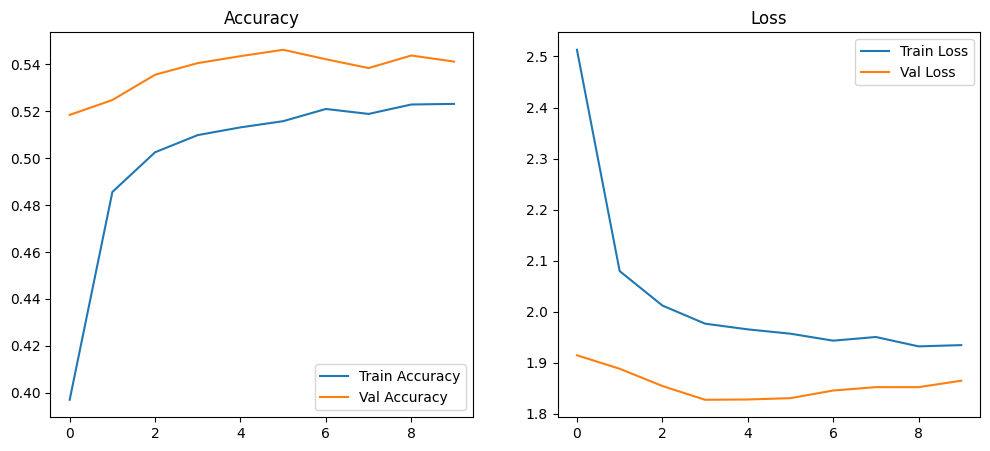

In [54]:
history=model.fit(train_ds,validation_data=val_ds,epochs=10)
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()

In [56]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_epochs = 5
total_epochs = 10 + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=history.epoch[-1] + 1,
    epochs=total_epochs
)

Epoch 11/15
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 219s 109ms/step - accuracy: 0.4262 - loss: 2.3764 - val_accuracy: 0.5481 - val_loss: 1.8029
Epoch 12/15
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 198s 103ms/step - accuracy: 0.5182 - loss: 1.8800 - val_accuracy: 0.5683 - val_loss: 1.6952
Epoch 13/15
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 200s 103ms/step - accuracy: 0.5506 - loss: 1.7405 - val_accuracy: 0.5855 - val_loss: 1.6158
Epoch 14/15
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 200s 102ms/step - accuracy: 0.5752 - loss: 1.6349 - val_accuracy: 0.5986 - val_loss: 1.5644
Epoch 15/15
1894/1894 ━━━━━━━━━━━━━━━━━━━━ 191s 100ms/step - accuracy: 0.5885 - loss: 1.5627 - val_accuracy: 0.6089 - val_loss: 1.5215


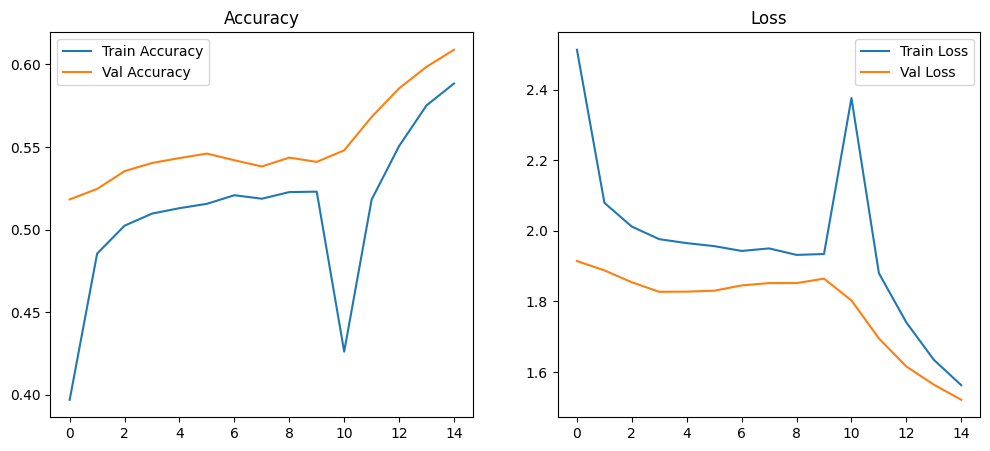

In [58]:
acc += history_fine.history["accuracy"]
val_acc += history_fine.history["val_accuracy"]
loss += history_fine.history["loss"]
val_loss += history_fine.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Val Loss")
plt.legend()
plt.title("Loss")
plt.show()

In [59]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")

790/790 ━━━━━━━━━━━━━━━━━━━━ 60s 76ms/step - accuracy: 0.6629 - loss: 1.2421
Test accuracy: 0.6629


In [60]:
model.save("food101_mobilenetv2.keras")
import json
with open("classes.json", "w") as f:
    json.dump(classes, f)
from google.colab import files
files.download("food101_mobilenetv2.keras")
files.download("classes.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>